# Описание задачи
Нашей команде было необходимо создайть сверточную сеть бинарной классификации, которая будет отличать настоящие лица от сгенерированных.

Нам были предоставлены  изображения лиц людей размером 256×256 пикселей:

* Реальные лица - фотографии людей с сайта Flickr

* Синтетические лица - сгенерированы с помощью StyleGAN


## Предоставленные данные

* **train_images** - 50 000 изображений для обучения

* **test_images** - 10 000 изображений для тестирования

* **train_solution** - метки классов для обучающей выборки

In [13]:
import os
import re
import torch

import pandas as pd
import numpy as np

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split


In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path, header=None)
        self.img_dir = img_dir
        self.transform = transform
        
        # Получаем список файлов и сортируем их ЧИСЛОВО: 0.jpg, 1.jpg, 2.jpg...
        all_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.image_files = sorted(all_files, key=natural_sort_key)
        
        # Проверка соответствия
        print(f"Проверка порядка Train: {self.image_files[:5]}") 
        # Должно напечатать: ['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg']
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label = self.df.iloc[idx, 1]
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        # В ТЕСТЕ тоже важна числовая сортировка, чтобы submission не перемешался
        all_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.image_files = sorted(all_files, key=natural_sort_key)
        
        print(f"Проверка порядка Test: {self.image_files[:5]}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

# Обработка данных

## Аугментации
Мы их используем по двум причинам:
1) С помощью поворотов мы боремся с переобучением. Благодаря ним нейросеть ищет инвариантные признаки, а не привязывается к координатам конкретных точек
2) Сгенерированные картинки обычно имеет более высокое качество, и чтобы модель не выучила эту простую зависимость, необходимо поменять яркость и контраст изображений

Также с помощью **Normalize** мы приводим распределение значений пикселей к стандартному

Благодаря аугментациям наша модель становится устойчивее к различным условиям съемки и перестает концентрироваться на артефактах освещения и т.д.

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
import kagglehub

kagglehub.login()

In [7]:
path = kagglehub.competition_download('ml-intensive-yandex-academy-spring-2026',
                                      output_dir='dataset')

print("Path to competition files:", path)

100%|██████████| 2.49G/2.49G [08:10<00:00, 5.46MB/s]

Extracting files...


Path to competition files: dataset


In [19]:
from torch.utils.data import DataLoader, Subset


train_csv = "dataset/dataset/train_solution.csv"
train_img_dir = "dataset/dataset/train_images"
test_img_dir = "dataset/dataset/test_images"

full_dataset = DeepfakeDataset(train_csv, train_img_dir, transform=train_transform)

labels = full_dataset.df.iloc[:, 1].values
train_idx, val_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

test_data = TestDataset(test_img_dir, transform=test_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


num_zeros = (labels == 0).sum()
num_ones = (labels == 1).sum()
pos_weight = torch.tensor([num_zeros / num_ones]).to(device)
print(f"Calculated pos_weight: {pos_weight.item():.4f}")

Проверка порядка Train: ['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg']
Проверка порядка Test: ['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg']
Calculated pos_weight: 4.8824


In [20]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np


def show_losses(train_loss_hist, val_loss_hist, 
                train_acc_hist, val_acc_hist):
    clear_output(wait=True)
    
    _, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
    

    ax1.plot(np.arange(len(train_loss_hist)), train_loss_hist, 
            label='Train Loss', color='blue', linewidth=1.5)
    ax1.plot(np.arange(len(val_loss_hist)), val_loss_hist, 
            label='Val Loss', color='orange', linewidth=1.5)
    ax1.set_title('Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_yscale('log')
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax1.legend(loc='upper right')
    
    ax2.plot(np.arange(len(train_acc_hist)), train_acc_hist, 
            color='green', linewidth=1.5)
    ax2.set_title('Train F1 Score (macro)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, ls="-", alpha=0.2)
    ax2.text(0.98, 0.02, f'{train_acc_hist[-1]*100:.2f}%', 
            transform=ax2.transAxes, fontsize=10, fontweight='bold',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.4))
    

    ax3.plot(np.arange(len(val_acc_hist)), val_acc_hist, 
            color='red', linewidth=1.5)
    ax3.set_title('Validation F1 Score (macro)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('F1 Score')
    ax3.set_ylim(0, 1.05)
    ax3.grid(True, ls="-", alpha=0.2)
    ax3.text(0.98, 0.02, f'{val_acc_hist[-1]*100:.2f}%', 
            transform=ax3.transAxes, fontsize=10, fontweight='bold',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.4))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Epoch {len(train_loss_hist)}: "
          f"Loss={train_loss_hist[-1]:.4f}/{val_loss_hist[-1]:.4f} | "
          f"Train F1={train_acc_hist[-1]*100:.2f}% | "
          f"Val F1={val_acc_hist[-1]*100:.2f}%")

# Обучение модели

Для обучения модели используется кастомная функция `run`, которая автоматизирует весь цикл обучения, отслеживает метрики и готовит финальный файл предсказаний. 
## Особенности реализации
* Вместо стандартного порога 0.5, функция после каждой эпохи на валидации ищет оптимальный порог в диапазоне от 0.1 до 0.9. Это позволяет найти баланс между точностью и полнотой в зависимости от уверенности модели.
* Реализован механизм мониторинга val_loss. Если ошибка на валидации не уменьшается в течение patience эпох (по умолчанию 3), обучение прерывается.
* Функция поддерживает разные типы планировщиков. Особое внимание уделено ReduceLROnPlateau: если лосс замирает, планировщик автоматически снижает LR, позволяя модели доучиться на более мелких шагах.
* В save_dir сохраняются веса только той эпохи, которая показала лучший F1-score на валидации. Именно эти веса загружаются перед финальным тестированием

In [21]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score

def run(epochs, model, optimizer, loss_function, 
              train_dataloader, val_dataloader, test_dataloader, 
              save_dir='checkpoints', scheduler=None, patience=3):
    
    try:
        tqdm._instances.clear()
    except:
        pass

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    train_loss_history, val_loss_history = [], []
    train_f1_history, val_f1_history = [], []
    
    best_val_f1 = 0
    best_threshold = 0.5
    
    # ПЕРЕМЕННЫЕ ДЛЯ EARLY STOPPING
    early_stop_counter = 0
    best_val_loss = float('inf')
    
    os.makedirs(save_dir, exist_ok=True)

    if hasattr(loss_function, 'pos_weight') and loss_function.pos_weight is not None:
        loss_function.pos_weight = loss_function.pos_weight.to(device)

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        epoch_train_losses = []
        all_train_preds, all_train_labels = [], []
        
        train_pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for batch_idx, (images, labels) in enumerate(train_pbar):
            images = images.to(device)
            labels = labels.to(device).float().view(-1, 1)
            
            optimizer.zero_grad()
            result = model(images)
            loss = loss_function(result, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step()
            
            epoch_train_losses.append(loss.item())
            
            probs = torch.sigmoid(result)
            preds = (probs > 0.5).float().cpu().numpy().flatten()
            all_train_preds.extend(preds)
            all_train_labels.extend(labels.cpu().numpy().flatten())
            
            if (batch_idx + 1) % 10 == 0:
                train_pbar.set_postfix({'loss': f'{np.mean(epoch_train_losses):.4f}', 'lr': f"{optimizer.param_groups[0]['lr']:.2e}"})
        
        avg_train_loss = np.mean(epoch_train_losses)
        train_f1 = f1_score(all_train_labels, all_train_preds, average='macro', zero_division=0)
        train_loss_history.append(avg_train_loss)
        train_f1_history.append(train_f1)

        # --- VALIDATION ---
        model.eval()
        epoch_val_losses = [] 
        val_probs, val_labels = [], []
        
        with torch.no_grad():
            for images, labels in tqdm(val_dataloader, desc="Val", leave=False):
                images = images.to(device)
                labels_v = labels.to(device).float().view(-1, 1)
                
                result = model(images)
                v_loss = loss_function(result, labels_v)
                epoch_val_losses.append(v_loss.item())
                
                val_probs.extend(torch.sigmoid(result).cpu().numpy().flatten())
                val_labels.extend(labels.numpy().flatten())

        # Поиск лучшего порога
        val_probs, val_labels = np.array(val_probs), np.array(val_labels)
        best_epoch_f1, best_epoch_thresh = 0, 0.5
        for threshold in np.arange(0.1, 0.9, 0.05):
            preds = (val_probs > threshold).astype(int)
            f1 = f1_score(val_labels, preds, average='macro', zero_division=0)
            if f1 > best_epoch_f1:
                best_epoch_f1, best_epoch_thresh = f1, threshold
        
        avg_val_loss = np.mean(epoch_val_losses)
        val_loss_history.append(avg_val_loss)
        val_f1_history.append(best_epoch_f1)

        # Отрисовка
        show_losses(train_loss_history, val_loss_history, train_f1_history, val_f1_history)
        
        print(f"Epoch {epoch+1:02d} | Val_Loss: {avg_val_loss:.4f} | Val_F1: {best_epoch_f1:.4f} | Thresh: {best_epoch_thresh:.2f}")

        # ЛОГИКА СОХРАНЕНИЯ И EARLY STOPPING
        if best_epoch_f1 > best_val_f1:
            best_val_f1 = best_epoch_f1
            best_threshold = best_epoch_thresh
            torch.save(model.state_dict(), os.path.join(save_dir, 'best_model.pt'))
            print("Лучшая модель сохранена")

        # Проверка на раннюю остановку по потере на валидации
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Ранняя остановка! переобучение!")
                break
        
        if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(avg_val_loss)

    # --- FINAL TESTING AND SUBMISSION ---
    print("\nИтоговый файл.")
    model.load_state_dict(torch.load(os.path.join(save_dir, 'best_model.pt')))
    model.eval()
    
    test_ids, test_preds = [], []
    
    with torch.no_grad():
        for images, ids in tqdm(test_dataloader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs > best_threshold).astype(int)
            
            test_preds.extend(preds)
            test_ids.extend(ids)

    # Убираем .jpg из всех ID перед сохранением
    clean_ids = [str(x).replace('.jpg', '') for x in test_ids]

    submission = pd.DataFrame({'id': clean_ids, 'target': test_preds})
    submission.to_csv('submission.csv', index=False)
    print(f"Submission saved. Best Threshold used: {best_threshold:.2f}")

    return best_threshold

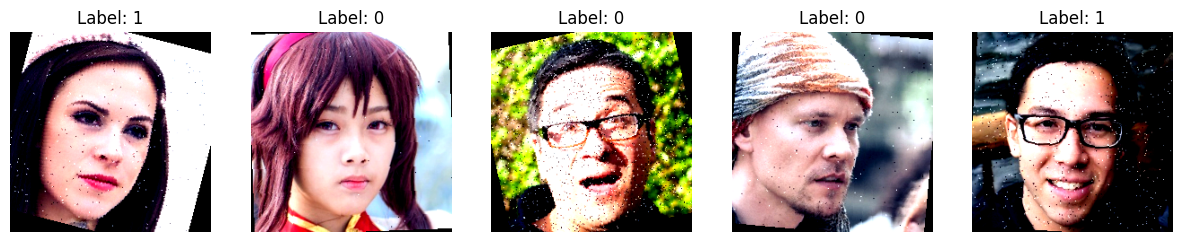

In [24]:
import matplotlib.pyplot as plt

def debug_dataset(dataset, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        
        # Денормировка для корректного отображения
        img = img.permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5 # если нормализация была (0.5, 0.5)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f"Label: {int(label.item())}")
        plt.axis('off')
    plt.show()

debug_dataset(train_dataset)

torch.Size([3, 224, 224])


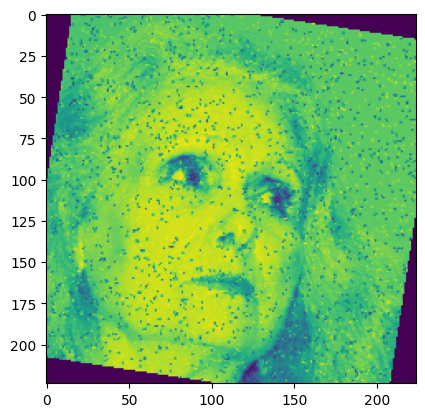

In [29]:
x, y = train_dataset[0]

plt.imshow(x[0])
print(x.shape)

# Архитектура нейронной сети

## Архитектура
Архитектура **XceptionNet** была выбрана из-за Separable-сверток (хз как переводится), что позволяет лучще улавливать пространственные закономерности (текстуру кожи, артефакты склейки), затрачивая меньше ресурсов, чем, например, модели с архитектурой Resnet


Ключевым компонентом этой архитектуры является разделение стандартной свертки на две: свертка 3x3 на каждый канал отдельно и свертка 1x1 для смещивания информации между каналами. Это снижает количество параметров и вычислительную сложность почти в 9 раз по сравнению с обычной сверткой, при этом практически не теряя в качестве. Для поиска дипфейков это позволяет строить глубокие сети, которые быстро обучаются

In [30]:
import torch
import torch.nn as nn


class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, bias=False):
        super(SeparableConv2d, self).__init__()
        self.sep_conv = nn.Sequential(
            # Глубинная свертка (по каждому каналу отдельно)
            nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, 
                      groups=in_channels, bias=bias, padding=1),
            # Точечная свертка (смешивание каналов)
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=bias)
        )

    def forward(self, x):
        return self.sep_conv(x)

class BasicConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(BasicConvBlock, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv_block(x)

class SeperableConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, use_relu=True):
        super(SeperableConvBlock, self).__init__()
        self.conv_block = nn.Sequential(
            SeparableConv2d(in_channels, out_channels, kernel_size),
            nn.BatchNorm2d(out_channels),
        )    
        self.relu = nn.ReLU()
        self.use_relu = use_relu
        
    def forward(self, x):
        x = self.conv_block(x)
        return self.relu(x) if self.use_relu else x

class SeperableResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SeperableResidualConvBlock, self).__init__()
        self.relu = nn.ReLU()
        self.first_block = SeperableConvBlock(in_channels, in_channels, 3, use_relu=True)
        self.second_block = SeperableConvBlock(in_channels, in_channels, 3, use_relu=False)
        # Слой для изменения размерности residual пути
        self.res_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2)

    def forward(self, x):
        residual = x
        x = self.first_block(x)
        x = self.second_block(x)
        
        # Чтобы сложить тензоры, нам нужно сжать residual
        # Мы используем MaxPool, чтобы быстро подогнать размер под stride=2
        residual = nn.functional.max_pool2d(residual, kernel_size=3, stride=2, padding=1)
        
        # Если каналов стало больше, подгоняем их через 1x1 свертку в другом месте, 
        # но здесь мы просто прогоним через res_conv
        res_connection = self.res_conv(x) 
        return self.relu(res_connection)

class XceptionNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1):
        super(XceptionNet, self).__init__()
        
        # 1. Начальный блок
        self.entry_flow = nn.Sequential(
            BasicConvBlock(in_channels, 32, 3, stride=2, padding=1),
            BasicConvBlock(32, 64, 3, stride=1, padding=1)
        )

        # 2. Тело модели (Residual блоки)
        layers = []
        last_out = 64
        for size in [128, 256, 512, 728]:
            layers.append(SeperableResidualConvBlock(last_out, size))
            last_out = size
        
        layers.append(SeperableConvBlock(last_out, 1024, 3, use_relu=True))
        self.features = nn.Sequential(*layers)

        # --- МАГИЯ ГИБКОСТИ ---
        # Этот слой сожмет признаки в 1024 x 2 x 2 независимо от входа
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # 3. Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(1024 * 2 * 2, 1024), # Теперь это всегда 4096
            nn.ReLU(),
            nn.Linear(1024, num_classes) 
            # Sigmoid убрали, так как используем BCEWithLogitsLoss
        )
    
    def forward(self, x):
        x = self.entry_flow(x)
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

In [31]:
xnet = XceptionNet(in_channels=3, num_classes=1)
xnet

XceptionNet(
  (entry_flow): Sequential(
    (0): BasicConvBlock(
      (conv_block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (1): BasicConvBlock(
      (conv_block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
  )
  (features): Sequential(
    (0): SeperableResidualConvBlock(
      (relu): ReLU()
      (first_block): SeperableConvBlock(
        (conv_block): Sequential(
          (0): SeparableConv2d(
            (sep_conv): Sequential(
              (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bi

## Функция потерь
Используется функция **BCEWithLogitsLoss** по следующим причинам:
1) Можно задать вес для опр.класса, что необходимо при их дисбалансе, как в нашем случае.
2) В отличие от стандартной BCELoss, она объединяет слой сигмоиды и бинарную кросс-энтропию в одном классе. Это обеспечивает высокую численную стабильность, предотвращая появление ошибок NaN при вычислении логарифмов от чисел, близких к 0 или 1. Кроме того, это позволяет модели решить проблему затухающих градиентов

In [32]:
xnet_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
xnet_optim = torch.optim.Adam(xnet.parameters(), lr=4e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    xnet_optim, 
    mode='min',       # 'min' означает, что мы следим за уменьшением лосса
    factor=0.5,       # Умножаем текущий LR на 0.5 (снижаем в два раза)
    patience=2,       # Сколько эпох ждать "застоя", прежде чем снизить LR
    threshold=1e-4,   # Порог, ниже которого изменения считаются "застоем"

)

# Результаты обучения и значение метрики F1

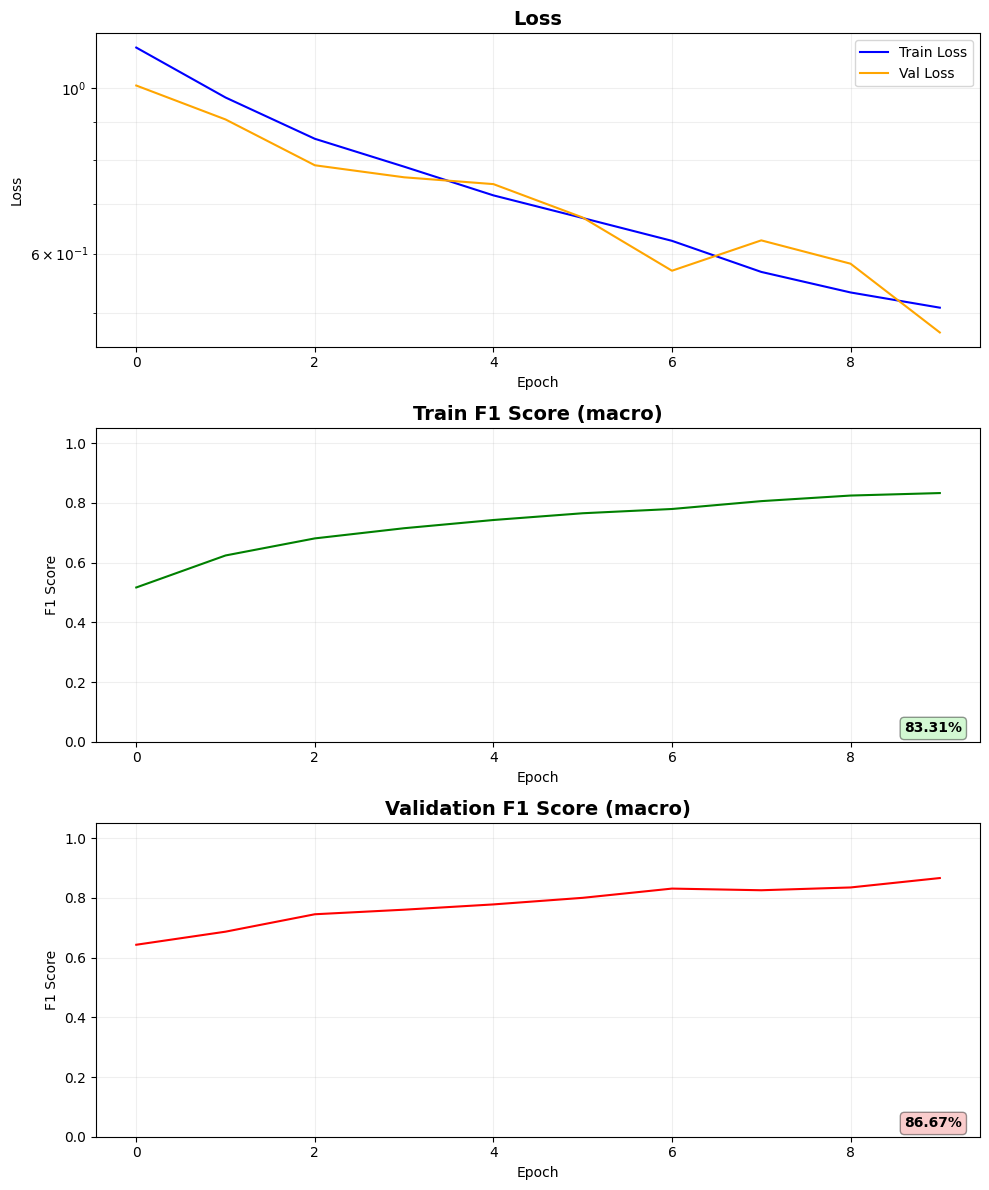

Epoch 10: Loss=0.5078/0.4704 | Train F1=83.31% | Val F1=86.67%
Epoch 10 | Val_Loss: 0.4704 | Val_F1: 0.8667 | Thresh: 0.80
Лучшая модель сохранена

Итоговый файл.


Predicting:   0%|          | 0/313 [00:00<?, ?it/s]

✅ Done! Submission saved. Best Threshold used: 0.80


np.float64(0.8000000000000002)

In [ ]:
run(epochs=10, 
    model=xnet, 
    optimizer=xnet_optim, 
    loss_function=xnet_loss, 
    train_dataloader=train_loader, 
    val_dataloader=val_loader, 
    test_dataloader=test_loader)